# IMPORTING LIBRARIES

In [1]:
import os
import sys
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn

from sklearn.model_selection import train_test_split

import albumentations as A

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

from config import (
    TRAIN_PATH,
    TEST_PATH,
    DEVICE,
    BATCH_SIZE,
    LEARNING_RATE,
    NUM_EPOCHS,
    MODEL_PATH
)

# READING TRAIN IMAGES

In [2]:
all_train_images = []
all_train_masks = []

for file in os.listdir(TRAIN_PATH):
    if file.endswith(".png"):
        if "_GT" not in file:
            all_train_images.append(file)
        else:
            all_train_masks.append(file)

print("Training Images:", len(all_train_images))
print("Training Masks:", len(all_train_masks))

Training Images: 2332
Training Masks: 2332


# READING TEST FILES

In [3]:
test_images = []
test_masks = []

for file in os.listdir(TEST_PATH):
    if file.endswith(".png"):
        if "_GT" not in file:
            test_images.append(file)
        else:
            test_masks.append(file)

print("Test Images:", len(test_images))
print("Test Masks:", len(test_masks))

Test Images: 1004
Test Masks: 1004


# VERIFYING PAIRING

In [4]:
sample = all_train_images[0]
print(sample)

mask = sample.replace(".png","_GT.png")
print(mask)

10000.png
10000_GT.png


# READING ONE IMAGE

In [5]:
image_path = os.path.join(TRAIN_PATH,sample)
mask_path = os.path.join(TRAIN_PATH,mask)

image = cv2.imread(image_path)
mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)

print(image.shape)
print(mask.shape)

(645, 229, 3)
(645, 229)


# DISPLAYING IMAGE + MASK

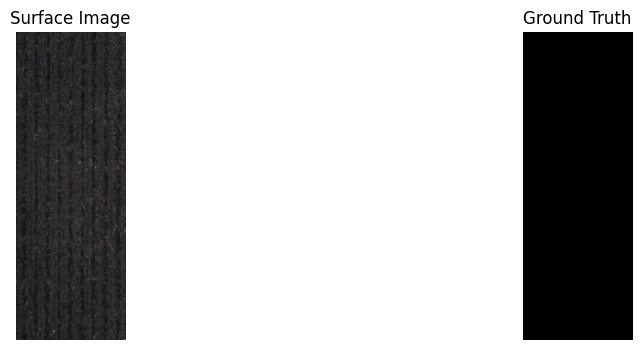

In [6]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)

plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))

plt.title("Surface Image")
plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(mask,cmap="gray")

plt.title("Ground Truth")
plt.axis("off")
plt.show()

In [7]:
defect_count = 0

for mask_file in all_train_masks:
    mask_path = os.path.join(TRAIN_PATH,mask_file)
    mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)

    if np.max(mask) > 0:
        defect_count += 1

print("Defective images:", defect_count)
print("Non-defective images:", len(all_train_masks) - defect_count)

Defective images: 247
Non-defective images: 2085


 Dataset Statistics

Total Images: 2332

Defective Images: 247

Non-Defective Images: 2085

Defect Percentage: 10.6%
Non-Defect Percentage: 89.4%

# CREATING FULL IMAGE AND MASK PATHS

In [8]:
all_image_files = []
all_mask_files = []

for file in all_train_images:

    # Skip copied images
    if "(copy)" in file:
        continue

    image_path = os.path.join(TRAIN_PATH,file)
    mask_path = os.path.join(TRAIN_PATH,file.replace(".png","_GT.png"))

    all_image_files.append(image_path)
    all_mask_files.append(mask_path)

print("Images :", len(all_image_files))
print("Masks  :", len(all_mask_files))

Images : 2331
Masks  : 2331


# CREATING TRAIN/VALIDATION SPLIT

In [12]:
train_imgs, val_imgs, train_masks, val_masks = train_test_split(all_image_files,all_mask_files,test_size=0.2,random_state=42,shuffle=True)

print("Training images :", len(train_imgs))
print("Validation images :", len(val_imgs))

Training images : 1864
Validation images : 467


# CREATING AUGMENTATION PIPELINE

In [9]:
train_transform = A.Compose([

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.RandomBrightnessContrast(p=0.3),

    A.Rotate(limit=10,p=0.5)
])

val_transform = None

# IMPORTING DATASET CLASS

In [10]:
from dataset import SurfaceDataset

# CREATING DATASETS

In [13]:
train_dataset = SurfaceDataset(train_imgs,train_masks,transform=train_transform)

val_dataset = SurfaceDataset(val_imgs,val_masks,transform=val_transform)

# CREATING DATALOADERS

In [14]:
train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True,num_workers=0)

val_loader = DataLoader(val_dataset,batch_size=16,shuffle=False,num_workers=0)

# VERIFYING DATALOADERS SHAPES

In [15]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

torch.Size([16, 3, 256, 256])
torch.Size([16, 1, 256, 256])


# VISUALISING ONE BATCH

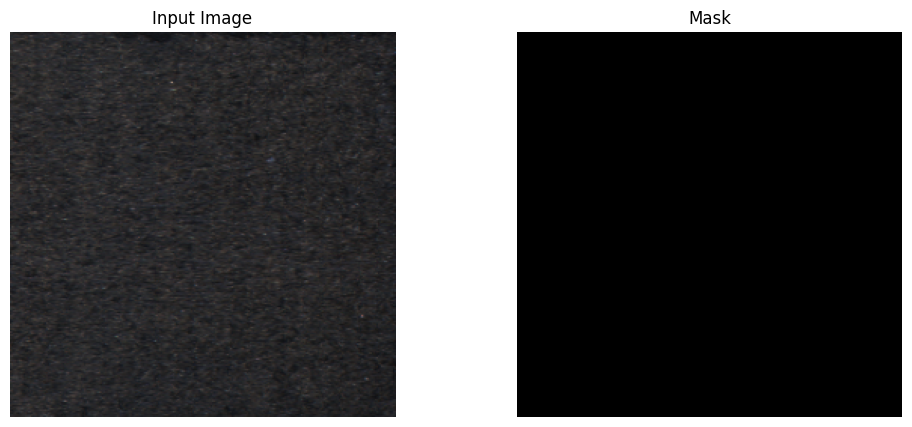

In [16]:
image = images[0]
mask = masks[0]

image = image.permute(1,2,0).numpy()
mask = mask.squeeze().numpy()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)

plt.imshow(image)

plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(mask,cmap="gray")

plt.title("Mask")
plt.axis("off")
plt.show()

# U-Net

# Creating the model

In [17]:
from model import UNet

model = UNet().to(DEVICE)

print(model)

UNet(
  (enc1): EncoderBlock(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (enc2): EncoderBlock(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (enc3): EncoderBlock(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
   

# Choosing loss function

In [18]:
criterion = nn.BCEWithLogitsLoss()

* Why BCEWithLogitsLoss?

our network outputs
[1,1,256,256]

Those values are raw scores.
Example
-4.8
2.7
0.9
-0.3
They are not probabilities.

BCEWithLogitsLoss internally performs

Sigmoid
↓
Binary Cross Entropy

So we do not add a Sigmoid layer inside the model.

# Optimizer

In [19]:
optimizer = torch.optim.Adam( model.parameters(), lr=LEARNING_RATE)

# Training (1 epoch)

In [39]:
model.train()

train_loss = 0.0

for images, masks in train_loader:

    images = images.to(device)
    masks = masks.to(device)

    outputs = model(images)
    loss = criterion(outputs,masks)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    train_loss += loss.item()

train_loss /= len(train_loader)

print(train_loss)

0.048092367146194026


# Validation (1 epoch)

In [54]:
model.eval()

val_loss = 0.0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = criterion( outputs, masks)

        val_loss += loss.item()

val_loss /= len(val_loader)

print(val_loss)

0.02139121632790193


## Dice Score Function

## IoU Function

In [44]:
from utils import dice_score, iou_score

# Complete Training pipeline

In [61]:
train_losses = []
val_losses = []
dice_scores = []
iou_scores = []

best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):

    # Training

    model.train()

    train_loss = 0.0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation

    model.eval()

    val_loss = 0.0
    epoch_dice = 0.0
    epoch_iou = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            val_loss += loss.item()
            epoch_dice += dice_score(outputs, masks)
            epoch_iou += iou_score(outputs, masks)

        val_loss /= len(val_loader)
        epoch_dice /= len(val_loader)
        epoch_iou /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    dice_scores.append(epoch_dice)
    iou_scores.append(epoch_iou)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Dice Score      : {epoch_dice:.4f}")
    print(f"IoU Score       : {epoch_iou:.4f}")

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save( model.state_dict(), MODEL_PATH)

        print("Best Model Saved")

    print("-"*50)

Epoch 1/20
Train Loss      : 0.0156
Validation Loss : 0.0152
Dice Score      : 0.1000
IoU Score       : 0.1000
Best Model Saved
--------------------------------------------------
Epoch 2/20
Train Loss      : 0.0160
Validation Loss : 0.0148
Dice Score      : 0.0374
IoU Score       : 0.0354
Best Model Saved
--------------------------------------------------
Epoch 3/20
Train Loss      : 0.0155
Validation Loss : 0.0150
Dice Score      : 0.1352
IoU Score       : 0.0870
--------------------------------------------------
Epoch 4/20
Train Loss      : 0.0157
Validation Loss : 0.0147
Dice Score      : 0.1613
IoU Score       : 0.1051
Best Model Saved
--------------------------------------------------
Epoch 5/20
Train Loss      : 0.0151
Validation Loss : 0.0142
Dice Score      : 0.2281
IoU Score       : 0.1499
Best Model Saved
--------------------------------------------------
Epoch 6/20
Train Loss      : 0.0153
Validation Loss : 0.0142
Dice Score      : 0.2645
IoU Score       : 0.1778
Best Model 

# Plotting training & validation loss

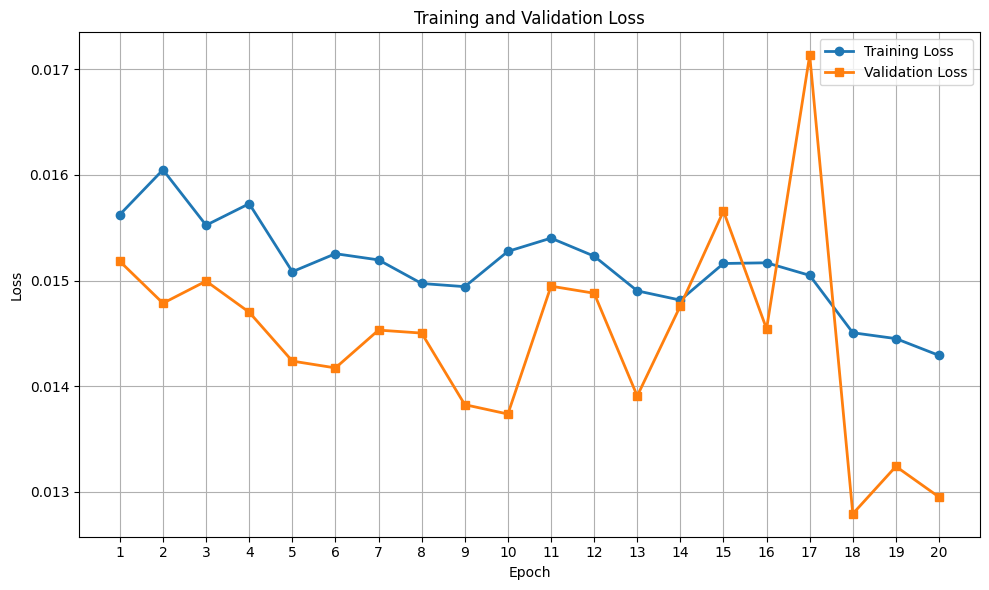

In [66]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(10, 6))

plt.plot( epochs, train_losses, marker='o', linewidth=2, label="Training Loss")
plt.plot( epochs, val_losses, marker='s', linewidth=2, label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.xticks(epochs)

plt.grid(True)

plt.legend()
plt.tight_layout()
plt.show()

# Plotting Dice Score & IoU Score

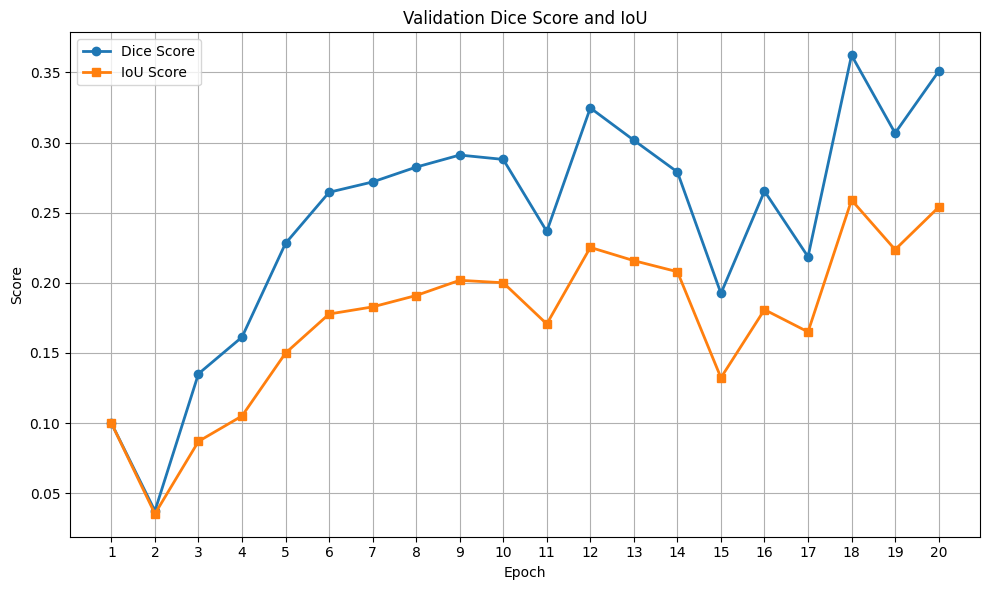

In [67]:
plt.figure(figsize=(10,6))

plt.plot( epochs, dice_scores, marker='o', linewidth=2, label="Dice Score")

plt.plot( epochs, iou_scores, marker='s', linewidth=2, label="IoU Score")

plt.title("Validation Dice Score and IoU")
plt.xlabel("Epoch")
plt.ylabel("Score")

plt.xticks(epochs)

plt.grid(True)

plt.legend()
plt.tight_layout()
plt.show()